# APL case study: Boolean network analyses

This notebook explores the subset-minimal Boolean networks inferred by scBOLT for the PLZF-RARα APL case study. It documents the selected components, the structural properties of the inferred network ensemble, and the resulting attractor landscapes.

Each section introduces the corresponding modelling question and reproduces the analyses used to interpret the Boolean networks in the manuscript.

### Table of contents

1. [Data overview](#data)
2. [Structural properties](#structure)
3. [Gene selection enrichment analysis](#enrichment)
4. [Pairwise macrostate distances](#distances)
5. [Reference APL model attractors](#reference-model)
6. [Reachable attractors](#attractors)
7. [Subset-minimal Boolean networks](#minimal)

### Figure index <a class="anchor" id="figure-index"></a>

The notebook exports the following figures. Links jump to the section where each figure is generated.

| Notebook section | Generated file |
| --- | --- |
| [Structural properties: function families](#fig-function-families) | `bn_function_families.pdf` |
| [Structural properties: feedback core](#fig-feedback-core) | `bn_feedback_core.pdf` |
| [Gene selection enrichment: top GO BP terms](#fig-goea-bp) | `bn_goea_bp_top20.pdf` |
| [Reference-model attractor comparison](#fig-reference-model) | `reference_model_state_comparison.pdf` |


In [9]:
# --------------
# Notebook setup
# --------------

%matplotlib inline

# Standard library

import gzip
import logging
import os
import urllib.request
from collections import defaultdict
from itertools import combinations
from pathlib import Path

# Third-party packages

logging.getLogger("colomoto_jupyter").setLevel(logging.ERROR)
import mpbn
import bonesistools as bt

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS
from goatools.obo_parser import GODag

from IPython.display import display

# Global display and plotting settings

pd.set_option("future.no_silent_downcasting", True)
bt.omics.pl.set_default_params()

plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 16

# Case-study directories

def find_project_root(start=None, markers=(".git", "apl")):
    """Locate the case-study root directory from any notebook location."""

    start = Path.cwd() if start is None else Path(start).resolve()

    for path in (start, *start.parents):
        if all((path / marker).exists() for marker in markers):
            return path

    raise FileNotFoundError(
        f"Could not find project root from {start} using markers {markers}"
    )

PROJECT_DIR = find_project_root()
APL_DIR = PROJECT_DIR / "apl"

DATA_DIR = APL_DIR / "data"
FIGURE_DIR = APL_DIR / "figures"
GO_DIR = PROJECT_DIR / "public" / "go"
GENE2GO_FILE = (
    GO_DIR / "gene2go.gz"
    if (GO_DIR / "gene2go.gz").exists()
    else GO_DIR / "gene2go"
)
REFERENCE_MODEL_DIR = DATA_DIR / "reference"
REFERENCE_MODEL_URL = (
    "https://ginsim.github.io/models/"
    "2024-mammal-promyelocytic-leukaemia/"
    "SanchezVillanueva_RA_APL_model_19Nov2024.zginml"
)
REFERENCE_MODEL_FILE = (
    REFERENCE_MODEL_DIR / "SanchezVillanueva_RA_APL_model_19Nov2024.zginml"
)

FIGURE_DIR.mkdir(exist_ok=True)

# Biological settings

conditions = ["ctrl", "treated"]
labels_order = ["Prom1", "Prom2", "Rep", "Cycl", "Neu", "Alt"]
go_category_to_namespace = {"Process": "BP", "Function": "MF", "Component": "CC"}

GENEINFO_VERSION = "bundled"
PRIOR_KNOWLEDGE = "dorothea"
DOROTHEA_API = "legacy"
DOROTHEA_LEVELS = ["A"]
DOROTHEA_COMPATIBILITY = True
OMNIPATH_VERSION = "2025-08-13"
HCOP_VERSION = "bundled"

REFERENCE_MODEL_ATRA_LABELS = {
    "noRA": "no ATRA",
    "RAphys": "physiological ATRA",
    "RAphar": "pharmacological ATRA",
}
REFERENCE_MODEL_PHENOTYPES = {
    "proliferative": ["E2F1", "MYC"],
    "arrested": ["CDKN1A", "CDKN1B", "TP53"],
    "differentiated": ["SPI1", "CEBPAB", "RARB"],
}
REFERENCE_MODEL_PHENOTYPE_PRIORITY = [
    "differentiated",
    "arrested",
    "proliferative",
]
REFERENCE_MODEL_ALIASES = {"CAK": "CDK7"}
REFERENCE_MODEL_PROTECTED_COMPONENTS = {
    "RA_b1",
    "RA_b2",
    "PML_RARAg",
    "PLZF_RARAg",
    "PML_RARA",
    "PLZF_RARA",
    "CoAct_COMP",
    "CoRep_COMP",
    "PRC2",
    "CEBPAB",
    "CDK4_6",
}
REFERENCE_MODEL_SC_BOLT_COMPONENTS = {
    "CDK4_6": ["Cdk4", "Cdk6"],
}
REFERENCE_MODEL_COLUMN_LABELS = {
    ("CDK4_6", "Cdk4"): "Cdk4",
    ("CDK4_6", "Cdk6"): "Cdk6",
}
REFERENCE_MODEL_PANEL_COMPONENTS = [
    "Ccna2",
    "CDK4_6",
    "E2f1",
    "Myc",
    "Ezh2",
    "Trp53",
    "Cdkn1a",
    "Pml",
    "Spi1",
]

genesyn = bt.resources.ncbi.genesyn(
    organism="mouse",
    version=GENEINFO_VERSION,
)
human_genesyn = bt.resources.ncbi.genesyn(
    organism="human",
    version=GENEINFO_VERSION,
)
hcop_orthologs = bt.resources.hcop.orthologs(
    output_organism="mouse",
    version=HCOP_VERSION,
)



Helper functions are collected here so the analysis cells below stay focused on the figure-building steps.


In [10]:
def display_counts(counts, index_name="item", count_name="n"):
    """Display a compact count summary."""

    summary = pd.DataFrame(
        [(name, count) for name, count in counts.items()],
        columns=[index_name, count_name],
    )
    display(summary.style.hide(axis="index"))

def split_macrostate(name):
    condition, macrostate = name.split("_", 1)
    return condition, macrostate

def fixed_shared_components(hc1, hc2):
    """Return features fixed in both hypercubes."""

    return [
        component
        for component in hc1.components & hc2.components
        if hc1[component].is_fixed and hc2[component].is_fixed
    ]

def hypercube_distance(hc1, hc2):
    """Count mismatching binarised features between two hypercubes."""

    return sum(
        hc1[component] != hc2[component]
        for component in fixed_shared_components(hc1, hc2)
    )

def hypercube_maximum(hc1, hc2):
    """Count jointly defined features between two hypercubes."""

    return len(fixed_shared_components(hc1, hc2))

def as_mpbn_state(hypercube):
    """Convert a Hypercube to an mpbn-compatible partial state."""

    return {
        component: value.value
        for component, value in dict(hypercube).items()
        if value.is_fixed
    }

def download_if_missing(url, outfile):
    """Download a resource only when it is absent."""

    outfile.parent.mkdir(parents=True, exist_ok=True)
    if not outfile.exists():
        urllib.request.urlretrieve(url, outfile)
    return outfile

def translate_reference_model(reference_model):
    """Translate the Sanchez-Villanueva network and influence graph."""

    bn = reference_model.boolean_network.copy()
    influence_graph = reference_model.influence_graph.copy()
    for component in influence_graph:
        influence_graph.nodes[component]["reference_component"] = component

    for source, target in REFERENCE_MODEL_ALIASES.items():
        for structure in (bn, influence_graph):
            if source in structure:
                structure.rename(source, target)

    protected = sorted(
        REFERENCE_MODEL_PROTECTED_COMPONENTS
        & (set(bn) | set(influence_graph))
    )
    locks = {component: f"MODELLOCK{i}X" for i, component in enumerate(protected)}
    for component, lock in locks.items():
        for structure in (bn, influence_graph):
            if component in structure:
                structure.rename(component, lock)

    bn = human_genesyn.standardize_bn(bn, copy=True)
    bn = hcop_orthologs.translate_bn(bn, keep_if_missing=True, copy=True)
    bn = genesyn.standardize_bn(bn, copy=True)
    influence_graph = human_genesyn.standardize_graph(influence_graph, copy=True)
    influence_graph = hcop_orthologs.translate_graph(
        influence_graph,
        keep_if_missing=True,
        copy=True,
    )
    influence_graph = genesyn.standardize_graph(influence_graph, copy=True)

    for component, lock in locks.items():
        for structure in (bn, influence_graph):
            if lock in structure:
                structure.rename(lock, component)

    return bn, influence_graph

def consensus_config_value(configs, state_name, component):
    """Return the ensemble consensus for one component in one state."""

    values = []
    for config in configs:
        if state_name not in config:
            return np.nan

        state = config[state_name]
        if component not in state.components:
            return np.nan

        value = state[component]
        if not value.is_fixed:
            return np.nan
        values.append(value.value)

    unique_values = set(values)
    if len(unique_values) == 1:
        return unique_values.pop()
    return np.nan

def state_value_origin(mstate_hypercubes, state_name, component, value):
    """Report whether a scBOLT state value comes from binarisation or BoNesis."""

    if pd.isna(value):
        return np.nan

    if state_name not in mstate_hypercubes:
        return "BoNesis"

    mstate = mstate_hypercubes[state_name]
    if component not in mstate.components or not mstate[component].is_fixed:
        return "BoNesis"

    if mstate[component].value != value:
        return "conflict"

    return "binarisation"

def build_reference_panel_columns(reference_bn, scbolt_components):
    """Select reference-model components that can be compared to scBOLT states."""

    panel_columns = []
    mapped_components = []
    excluded_components = []

    for component in REFERENCE_MODEL_PANEL_COMPONENTS:
        candidates = REFERENCE_MODEL_SC_BOLT_COMPONENTS.get(component, [component])
        if isinstance(candidates, str):
            candidates = [candidates]

        present_candidates = [
            candidate
            for candidate in candidates
            if candidate in scbolt_components
        ]

        if component in reference_bn and present_candidates:
            for scbolt_component in present_candidates:
                label = REFERENCE_MODEL_COLUMN_LABELS.get(
                    (component, scbolt_component),
                    component,
                )
                panel_columns.append(
                    {
                        "label": label,
                        "reference_component": component,
                        "scbolt_component": scbolt_component,
                    }
                )
                if scbolt_component != component:
                    mapped_components.append((component, scbolt_component))
            continue

        if component not in reference_bn:
            reason = "absent from translated reference model"
        elif not present_candidates:
            reason = (
                "absent from scBOLT subset-minimal states ("
                + ", ".join(candidates)
                + ")"
            )
        else:
            reason = "not retained"
        excluded_components.append((component, reason))

    if not panel_columns:
        raise ValueError("No shared component between reference model and scBOLT states.")

    return panel_columns, mapped_components, excluded_components

def reference_state_comparison_table(
    reference_attractors,
    configs,
    mstate_hypercubes,
    panel_columns,
):
    """Build value and origin tables for the reference-model comparison panel."""

    rows = []
    origin_rows = []

    for state_label, attractor in reference_attractors.items():
        row = {"source": "reference model", "state": state_label}
        origin_row = {"source": "reference model", "state": state_label}

        for column in panel_columns:
            label = column["label"]
            row[label] = attractor.get(column["reference_component"], np.nan)
            origin_row[label] = np.nan

        rows.append(row)
        origin_rows.append(origin_row)

    scbolt_state_labels = {
        ("scBOLT ctrl", "Rep"): "ctrl_Rep",
        ("scBOLT ctrl", "Neu"): "ctrl_Neu",
        ("scBOLT ctrl", "Alt"): "ctrl_Alt",
        ("scBOLT treated", "Rep"): "treated_Rep",
        ("scBOLT treated", "Neu"): "treated_Neu",
    }

    for (source, state), config_name in scbolt_state_labels.items():
        row = {"source": source, "state": state}
        origin_row = {"source": source, "state": state}

        for column in panel_columns:
            label = column["label"]
            component = column["scbolt_component"]
            value = consensus_config_value(configs, config_name, component)

            row[label] = value
            origin_row[label] = state_value_origin(
                mstate_hypercubes,
                config_name,
                component,
                value,
            )

        rows.append(row)
        origin_rows.append(origin_row)

    labels = [column["label"] for column in panel_columns]
    state_table = (
        pd.DataFrame(rows)
        .set_index(["source", "state"])
        .loc[:, labels]
        .astype(float)
    )
    origin_table = (
        pd.DataFrame(origin_rows)
        .set_index(["source", "state"])
        .loc[:, labels]
    )

    return state_table, origin_table

def plot_binary_state_table(table, value_origin=None, ax=None):
    """Plot a binary state table with optional value-origin markers."""

    values = table.astype(float).to_numpy()
    origins = None if value_origin is None else value_origin.reindex_like(table).to_numpy()
    plot_values = np.where(np.isnan(values), 0.5, values)
    cmap = ListedColormap(["#2b5c9e", "#d9d9d9", "#b2182b"])
    norm = BoundaryNorm([-0.5, 0.25, 0.75, 1.5], cmap.N)

    if ax is None:
        fig_width = max(5, 0.65 * table.shape[1] + 3)
        fig_height = max(3, 0.35 * table.shape[0] + 1.2)
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    else:
        fig = ax.figure

    ax.imshow(plot_values, aspect="auto", cmap=cmap, norm=norm)
    ax.set_xticks(
        np.arange(table.shape[1]),
        labels=table.columns,
        rotation=45,
        ha="right",
    )
    ax.set_yticks(
        np.arange(table.shape[0]),
        labels=[f"{source} | {state}" for source, state in table.index],
    )
    ax.set_xticks(np.arange(-0.5, table.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, table.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1)
    ax.tick_params(axis="both", which="both", length=0, labelsize=11)

    marker_styles = {
        "binarisation": "s",
        "BoNesis": "o",
        "conflict": "X",
    }

    for row, col in np.ndindex(values.shape):
        value = values[row, col]
        if np.isnan(value):
            continue

        if origins is not None and isinstance(origins[row, col], str):
            ax.scatter(
                col,
                row,
                marker=marker_styles.get(origins[row, col], "o"),
                s=280,
                facecolors="none",
                edgecolors="black",
                linewidths=1.4,
                zorder=3,
            )

        ax.text(
            col,
            row,
            str(int(value)),
            ha="center",
            va="center",
            fontsize=10,
            zorder=4,
        )

    if origins is not None:
        observed_origins = {
            origin
            for origin in pd.Series(origins.ravel()).dropna().unique()
            if origin in marker_styles
        }
        legend_labels = {
            "binarisation": "binarisation",
            "BoNesis": "BoNesis completion",
            "conflict": "mismatch",
        }
        handles = [
            Line2D(
                [0],
                [0],
                marker=marker_styles[origin],
                color="black",
                linestyle="None",
                markersize=5.5,
                markerfacecolor="none",
                label=legend_labels[origin],
            )
            for origin in ["binarisation", "BoNesis", "conflict"]
            if origin in observed_origins
        ]
        if handles:
            ax.legend(
                handles=handles,
                loc="upper left",
                bbox_to_anchor=(1.01, 1),
                frameon=False,
                fontsize=10,
                markerscale=1.0,
                handletextpad=1.0,
            )

    return fig, ax

def to_gene_ids(genes, genesyn):
    """Convert gene symbols to NCBI Gene IDs."""

    converted = genesyn(
        sorted(set(genes)),
        input_identifier_type="name",
        output_identifier_type="gene_id",
    )

    gene_ids = set()
    for gene_id in converted:
        if isinstance(gene_id, (int, np.integer)):
            gene_ids.add(int(gene_id))
        elif isinstance(gene_id, str) and gene_id.isnumeric():
            gene_ids.add(int(gene_id))

    return gene_ids

def read_gene2go_associations(path, gene_ids, tax_id=10090):
    """Read gene-to-GO associations for selected NCBI Gene IDs."""

    gene_ids = set(gene_ids)
    associations = {
        namespace: defaultdict(set)
        for namespace in go_category_to_namespace.values()
    }
    opener = gzip.open if path.suffix == ".gz" else open

    with opener(path, "rt") as reader:
        next(reader)
        for line in reader:
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 8 or fields[0] != str(tax_id):
                continue

            gene_id = int(fields[1])
            if gene_id not in gene_ids:
                continue

            namespace = go_category_to_namespace.get(fields[7])
            if namespace is not None:
                associations[namespace][gene_id].add(fields[2])

    return {namespace: dict(values) for namespace, values in associations.items()}

def goea_results_dataframe(results):
    """Convert GOATOOLS enrichment results to a compact dataframe."""

    return pd.DataFrame(
        [
            {
                "GO": result.GO,
                "NS": result.NS,
                "name": result.name,
                "enrichment": result.enrichment,
                "p_fdr_bh": result.p_fdr_bh,
                "study_count": result.study_count,
                "study_n": result.study_n,
                "pop_count": result.pop_count,
                "pop_n": result.pop_n,
            }
            for result in results
        ]
    )

def pairwise_hypercube_matrix(hypercubes, metric):
    """Build a symmetric pairwise matrix from a hypercube metric."""

    names = list(hypercubes)
    matrix = pd.DataFrame(np.nan, index=names, columns=names, dtype=float)

    for name in names:
        matrix.at[name, name] = metric(hypercubes[name], hypercubes[name])

    for name1, name2 in combinations(names, 2):
        value = metric(hypercubes[name1], hypercubes[name2])
        matrix.at[name1, name2] = value
        matrix.at[name2, name1] = value

    return matrix

def order_macrostate_matrix(matrix):
    """Order a macrostate matrix by condition and biological label."""

    matrix = matrix.copy()
    matrix.index = pd.MultiIndex.from_tuples(
        [split_macrostate(name) for name in matrix.index],
    )
    matrix.columns = pd.MultiIndex.from_tuples(
        [split_macrostate(name) for name in matrix.columns],
    )

    ordered_index = [
        (condition, label)
        for condition in conditions
        for label in labels_order
        if (condition, label) in matrix.index
    ]

    return matrix.loc[ordered_index, ordered_index].rename_axis(
        index=[None, None],
        columns=[None, None],
    )

def upper_triangle(matrix):
    """Hide the lower triangle of a square matrix."""

    mask = np.tril(np.ones(matrix.shape, dtype=bool), k=-1)
    return matrix.mask(mask)

def plot_counts(
    counts,
    title=None,
):
    if not counts:
        raise ValueError("counts must not be empty")

    keys = sorted(counts)
    values = [counts[key] for key in keys]

    fig, ax = plt.subplots()

    ax.bar(
        keys,
        values,
        width=1,
        facecolor=bt.omics.pl.get_color("pink"),
        edgecolor=bt.omics.pl.get_color("red"),
        linewidth=1.5,
    )

    ax.set_xlim(keys[0] - 0.6, keys[-1] + 0.6)
    ax.set_ylim(0, max(values) + 1)

    if title is not None:
        ax.set_title(title)

    return fig, ax

## Data overview <a class="anchor" id="data"></a>

### Load Boolean networks

Two objects generated by scBOLT are loaded:

* partially binarised macrostates;
* subset-minimal Boolean networks;

In [11]:
bn_dirs = sorted(
    [
        path
        for path in (DATA_DIR / "bn" / "submin").iterdir()
        if path.is_dir()
        and (path / "model.bnet").exists()
        and (path / "state.csv").exists()
    ],
    key=lambda path: int(path.name),
)

bns = []
configs = []
mpbn_configs = []

for path in bn_dirs:
    config = bt.logic.io.read_hypercubes(path / "state.csv", orientation="columns")

    bns.append(bt.logic.io.read_bnet(path / "model.bnet"))
    configs.append(config)
    mpbn_configs.append(
        {
            name: as_mpbn_state(hypercube)
            for name, hypercube in config.items()
        }
    )

bns = bt.logic.bn.BooleanNetworkEnsemble(bns=bns)
mpbns = bns.convert("mpbn")
components = bns.components

mstate_hypercubes = bt.logic.io.read_hypercubes(
    DATA_DIR / "mstates_bin.csv",
    orientation="rows",
)
features = set().union(*(hc.components for hc in mstate_hypercubes.values()))

mstate_hypercubes = {
    name: hc.drop(set(hc.components) - set(components))
    for name, hc in mstate_hypercubes.items()
}

#mstates_df = pd.read_csv(
#    DATA_DIR / "mstates_bin.csv",
#    index_col=0
#).fillna("*").replace("-", "_")
#features = set(mstates_df.columns)
#mstates_df = mstates_df[[component for component in components if component in mstates_df.columns]]

display_counts(
    {
        "macrostates": len(mstate_hypercubes),
        "boolean networks": len(bns),
        "components": len(components),
    },
    index_name="",
)

components_in_bin_and_bn = components.intersection(features)
components_in_bn_notin_bin = components.difference(features)

component_summary = display_counts(
    {
        "in binarisation": len(features),
        "in BNs": len(components),
        "intersection": len(components & features),
        "difference": len(components - features),
    },
    index_name="",
    count_name="n_components",
)


,n
macrostates,9
boolean networks,1000
components,193


,n_components
in binarisation,3228
in BNs,193
intersection,167
difference,26


## Structural properties <a class="anchor" id="structure"></a>

The aggregated influence graph summarises the regulatory structures retained across the subset-minimal Boolean-network ensemble. Edge frequencies quantify how consistently each interaction is selected, while node summaries describe the stability or diversity of the inferred Boolean functions.

### Function-family overview <a class="anchor" id="fig-function-families"></a>

Structurally equivalent components are grouped into families to provide a compact overview of the complete inferred network ensemble.

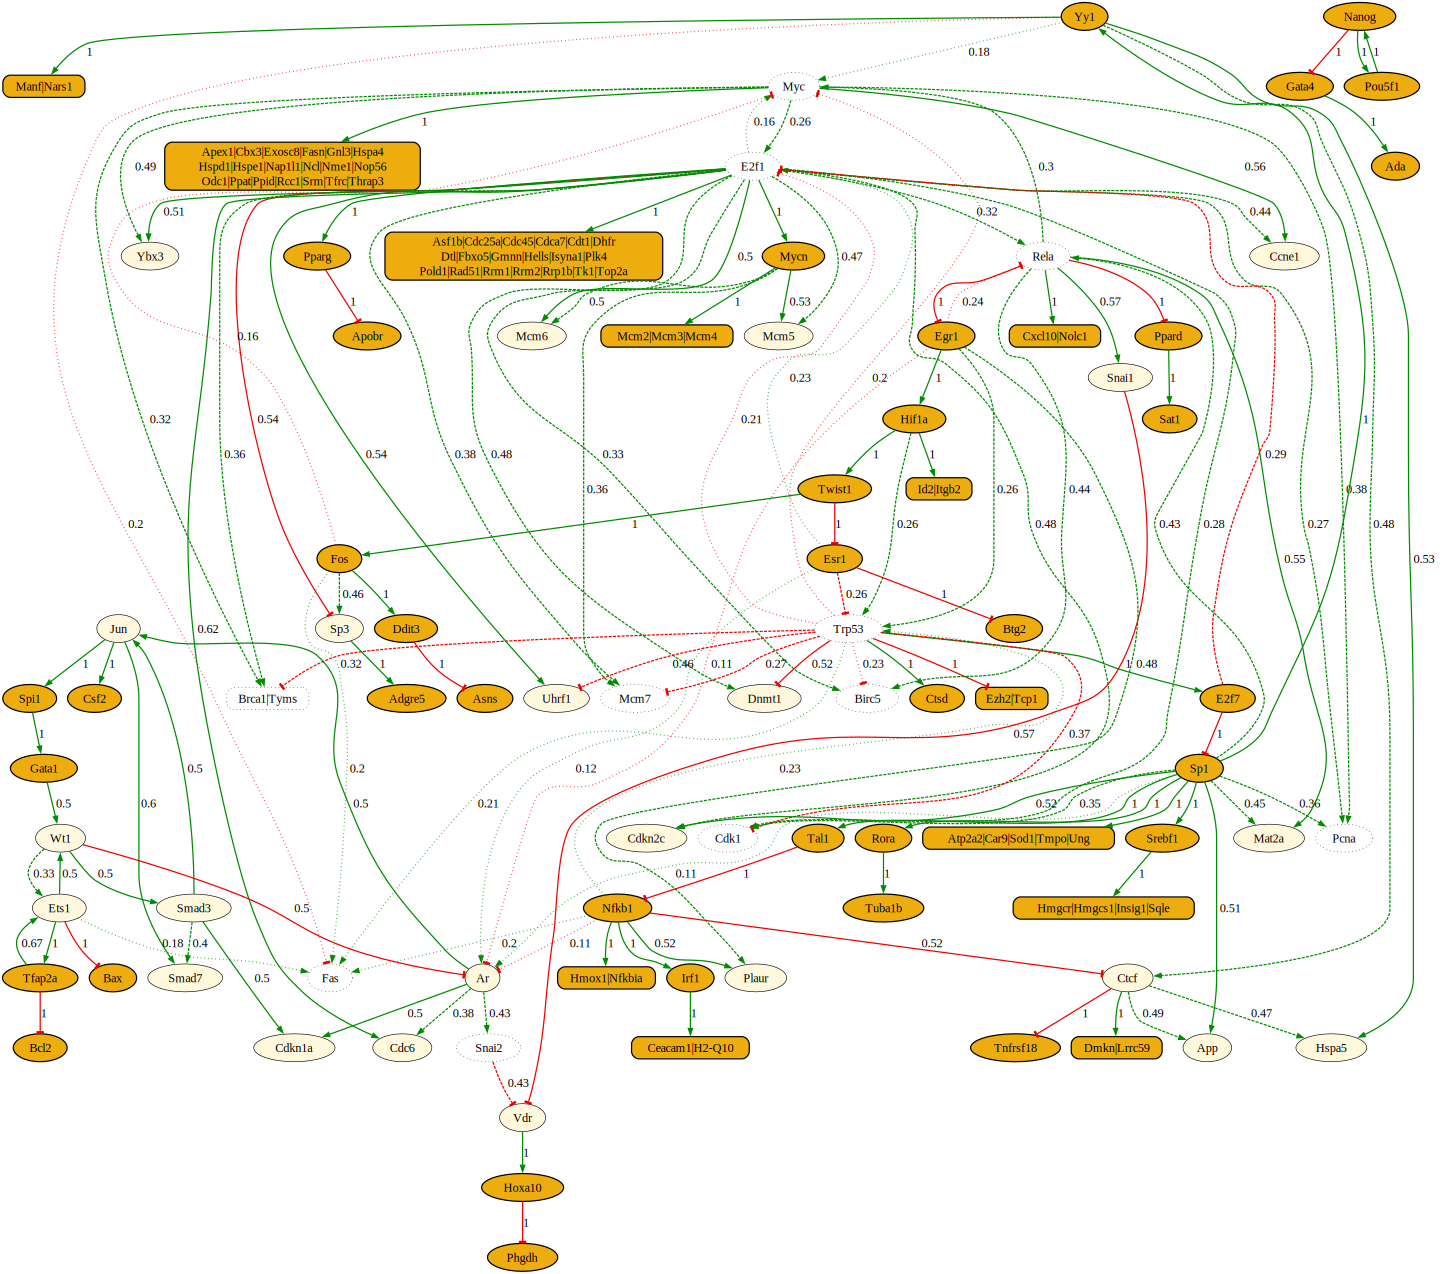

In [12]:
ig = bt.logic.ig.AggregatedInfluenceGraph.from_boolean_networks(bns)

function_family_options = {
    "collapse": "family",
    "drop_isolates": True,
    "edge_label": "frequency",
    "graph_attr": {
        "ratio": "compress",
        "size": "20,30!",
        "overlap": "prism",
        "sep": "+0",
        "esep": "+0",
        "K": "0.35",
        "ranksep": "0.6",
        "pack": "true",
        "rankdir": "TB",
        "splines": "curve",
    },
    "node_attr": {
        "fontsize": "20",
    },
    "node_style": "stability",
    "edge_attr": {
        "fontsize": "20",
    },
    "edge_style": "frequency",
}

ig.show(**function_family_options, width="100%")
ig.to_pydot(**function_family_options).write_pdf(
    str(FIGURE_DIR / "bn_function_families.pdf")
)

### Feedback core <a class="anchor" id="fig-feedback-core"></a>

Restricting the ensemble to feedback-associated components highlights the regulatory core most directly involved in the long-term dynamical behaviour.

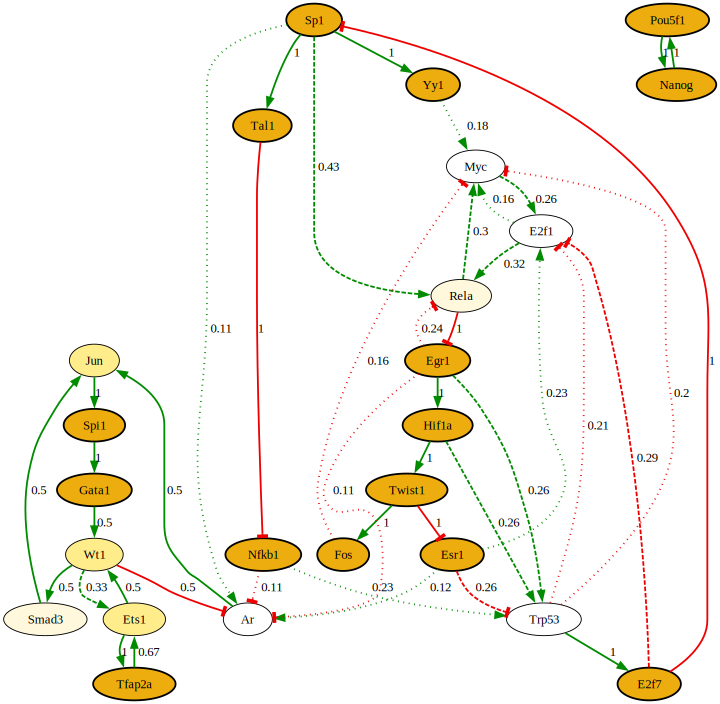

In [13]:
feedback_core_options = {
    "collapse": "both",
    "drop_isolates": True,
    "edge_label": "frequency",
    "node_style": "count",
    "preserve_feedback": True,
    "include_selfloops": False,
    "min_frequency": 0,
    "program": "dot",
    "graph_attr": {
        "ratio": "compress",
        "size": "10,10!",
        "rankdir": "TB",
        "splines": "curve",
        "ranksep": "0.25",
        "pack": "true",
        "sep": "+0",
        "esep": "+0",
        "K": "0.35",
        "overlap": "prism",
    },
}

ig.show(**feedback_core_options)
ig.to_pydot(**feedback_core_options).write_pdf(
    str(FIGURE_DIR / "bn_feedback_core.pdf")
)

## Gene selection enrichment analysis <a class="anchor" id="enrichment"></a>

The subset-minimal Boolean networks contain 193 unique components. These genes are tested for Gene Ontology enrichment using the DoRothEA legacy prior network used by scBOLT as background.

### Top enriched biological processes <a class="anchor" id="fig-goea-bp"></a>

The panel below reports the top 20 enriched biological process (BP) terms ranked by FDR.

set,n_genes
DoRothEA edges,2804
DoRothEA genes,1460
BoNesis components,193
GO-mapped BoNesis components,193
GO-mapped DoRothEA genes,1459


GO,name,p_fdr_bh,study_count,pop_count,minus_log10_fdr
GO:0000727,double-strand break repair via break-induced replication,4.49e-03,7,7,2.35
GO:0006270,DNA replication initiation,4.97e-03,9,12,2.30
GO:1902895,positive regulation of miRNA transcription,4.97e-03,18,43,2.30
GO:0006279,premeiotic DNA replication,8.72e-03,6,6,2.06
GO:0044027,negative regulation of gene expression via chromosomal CpG island methylation,2.55e-02,7,9,1.59
GO:0043066,negative regulation of apoptotic process,9.66e-02,42,182,1.01
GO:0045931,positive regulation of mitotic cell cycle,9.66e-02,9,17,1.01
GO:0007052,mitotic spindle organization,9.66e-02,6,8,1.01
GO:0044772,mitotic cell cycle phase transition,1.30e-01,5,6,0.89
GO:0010971,positive regulation of G2/M transition of mitotic cell cycle,1.30e-01,8,15,0.89


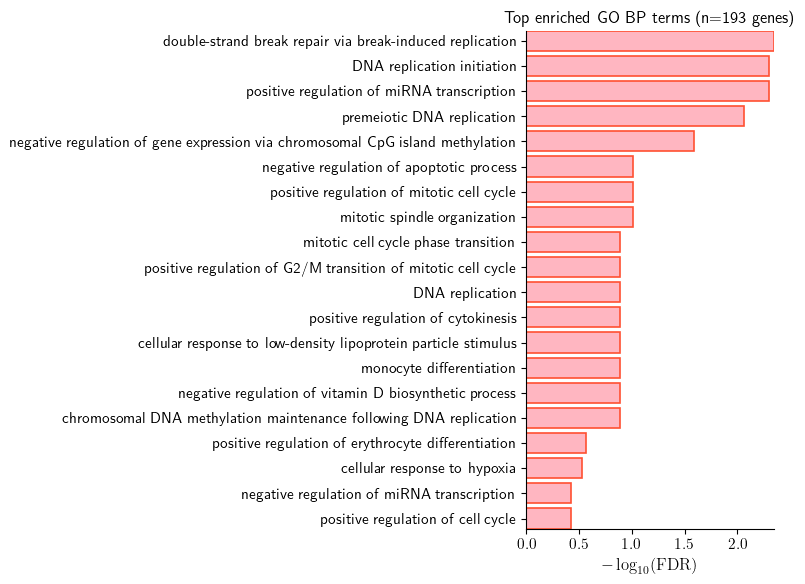

In [14]:
selected_genes = sorted(components)
prior_knowledge = bt.resources.omnipath.dorothea(
    organism="mouse",
    levels=DOROTHEA_LEVELS,
    genesyn=genesyn,
    version=OMNIPATH_VERSION,
    hcop_version=HCOP_VERSION,
    compatibility=DOROTHEA_COMPATIBILITY,
    flavor=DOROTHEA_API,
)
go_background = sorted(prior_knowledge.nodes)

selected_gene_ids = to_gene_ids(selected_genes, genesyn)
background_gene_ids = to_gene_ids(go_background, genesyn)
missing_gene_ids = selected_gene_ids - background_gene_ids

if missing_gene_ids:
    raise ValueError(
        f"{len(missing_gene_ids)} BoNesis component Gene IDs are absent from "
        "the DoRothEA background."
    )

display_counts(
    {
        "DoRothEA edges": prior_knowledge.number_of_edges(),
        "DoRothEA genes": len(go_background),
        "BoNesis components": len(selected_genes),
        "GO-mapped BoNesis components": len(selected_gene_ids),
        "GO-mapped DoRothEA genes": len(background_gene_ids),
    },
    index_name="set",
    count_name="n_genes",
)

with open(os.devnull, "w") as log:
    go_dag = GODag(str(GO_DIR / "go_basic.obo"), prt=log)

associations = read_gene2go_associations(
    GENE2GO_FILE,
    gene_ids=background_gene_ids,
)

with open(os.devnull, "w") as log:
    goea = GOEnrichmentStudyNS(
        pop=background_gene_ids,
        ns2assoc=associations,
        godag=go_dag,
        propagate_counts=False,
        alpha=0.05,
        methods=["fdr_bh"],
        log=log,
    )

with open(os.devnull, "w") as log:
    goea_results = goea_results_dataframe(
        goea.run_study(study_ids=selected_gene_ids, log=log)
    )

bp_enrichment = (
    goea_results
    .query("NS == 'BP' and enrichment == 'e'")
    .sort_values("p_fdr_bh", kind="mergesort")
    .reset_index(drop=True)
)
top_bp_terms = bp_enrichment.head(20).copy()

if top_bp_terms.empty:
    raise ValueError("No enriched GO BP term found for the BoNesis components.")

top_bp_terms["minus_log10_fdr"] = -np.log10(
    top_bp_terms["p_fdr_bh"].clip(lower=np.finfo(float).tiny)
)

display(
    top_bp_terms[
        ["GO", "name", "p_fdr_bh", "study_count", "pop_count", "minus_log10_fdr"]
    ]
    .style.hide(axis="index")
    .format({"p_fdr_bh": "{:.2e}", "minus_log10_fdr": "{:.2f}"})
)

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = top_bp_terms.iloc[::-1]

ax.barh(
    plot_df["name"],
    plot_df["minus_log10_fdr"],
    color=bt.omics.pl.get_color("pink"),
    edgecolor=bt.omics.pl.get_color("red"),
    linewidth=1.2,
)
ax.set_xlabel(r"$-\log_{10}(\mathrm{FDR})$", fontsize=12)
ax.set_ylabel(None)
ax.set_title(
    f"Top enriched GO BP terms (n={len(selected_genes)} genes)",
    fontsize=12,
)
ax.tick_params(axis="both", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "bn_goea_bp_top20.pdf", bbox_inches="tight")
plt.show()
plt.close()

## Pairwise macrostate distances <a class="anchor" id="distances"></a>

Pairwise distance matrix between macrostates based on the selected Boolean-network components. Each distance is the number of components that are defined in both macrostates and assigned different Boolean values. The corresponding maximum observable distance is the number of components defined in both macrostates, independently of whether their values match or differ. Pairwise similarity can therefore be computed as the maximum observable distance minus the observed distance.

In [15]:
distance = order_macrostate_matrix(
    pairwise_hypercube_matrix(mstate_hypercubes, hypercube_distance),
)
maximum = order_macrostate_matrix(
    pairwise_hypercube_matrix(mstate_hypercubes, hypercube_maximum),
)

distance_upper = upper_triangle(distance)
maximum_upper = upper_triangle(maximum)

display(
    distance_upper.style
    .set_caption("Pairwise macrostate distances")
    .format("{:.0f}", na_rep="")
)
display(
    maximum_upper.style
    .set_caption("Jointly binarised genes per macrostate pair")
    .format("{:.0f}", na_rep="")
)

## Reference APL model attractors <a class="anchor" id="reference-model"></a>

The Sanchez-Villanueva APL model is downloaded from the public GINsim model page at runtime and kept in a local cache ignored by git. The original model uses human gene symbols and several model-level variables or complexes; those non-gene components are protected before translation. Gene-like components in both the Boolean network and its influence graph are standardised with human NCBI GENEINFO, translated to mouse with HCOP, and standardised again with mouse NCBI GENEINFO.

The attractors below are computed with most-permissive semantics from the three `PLZF_RARA_*` initial states encoded directly in the published model. These configurations set the fusion-gene inputs (`PLZF_RARAg=1`, `PML_RARAg=0`) and the corresponding ATRA level, while the fusion-protein components evolve according to the model rules. Components without a clean counterpart in the scBOLT states are reported rather than coerced. The `CDK4_6` family component is compared with `Cdk4` and/or `Cdk6` when either family member is retained by the scBOLT inference. This is sufficient for a first comparison with the scBOLT states stored in `state.csv`; exact reproduction of the original asynchronous/general semantics would require an additional PyBoolNet or Colomoto stack.

### Phenotype signatures

Phenotype signatures follow the representative components used to annotate stable states in Figure 4 of the Sanchez-Villanueva study. Their original human identifiers are mapped through the translated influence graph so that the signatures and Boolean network use the same mouse symbols. The six context-specific results are then grouped by their internal state after excluding model inputs, yielding three attractors labelled `T1` to `T3`.

An attractor matches a signature when all its representative components are fixed to `1`. Because the differentiated attractor also activates the cell-cycle-arrest markers, phenotypes are assigned with the priority `differentiated`, `arrested`, then `proliferative`, reproducing the labels in Figure 4. Consequently, `T1` is proliferative, `T2` is arrested, and `T3` is differentiated. As ATRA increases, the arrested state is replaced by the differentiated state while the resistant proliferative state remains accessible.

### Reference-model attractor comparison <a class="anchor" id="fig-reference-model"></a>

The three internal reference-model attractors are compared with the scBOLT terminal states independently of ATRA level. The scBOLT `Rep` and `Neu` states respectively provide the closest proliferative and differentiated counterparts. `Alt` is retained as a distinct terminal state with a less direct, partly arrest-like interpretation. In the scBOLT rows, square markers denote values already fixed in `mstates_bin.csv`, while circle markers denote values completed by BoNesis in `state.csv`.


phenotype,components
proliferative,"E2f1, Myc"
arrested,"Cdkn1a, Cdkn1b, Trp53"
differentiated,"Spi1, CEBPAB, Rarb"


attractor,phenotype,accessible from
T1,proliferative,"no ATRA, physiological ATRA, pharmacological ATRA"
T2,arrested,no ATRA
T3,differentiated,"physiological ATRA, pharmacological ATRA"


item,n
reference-model components,37
unique internal MP attractors,3
MP attractors from no ATRA,2
MP attractors from physiological ATRA,2
MP attractors from pharmacological ATRA,2


reference component,scBOLT component
CDK4_6,Cdk6


component,reason
Pml,absent from scBOLT subset-minimal states (Pml)


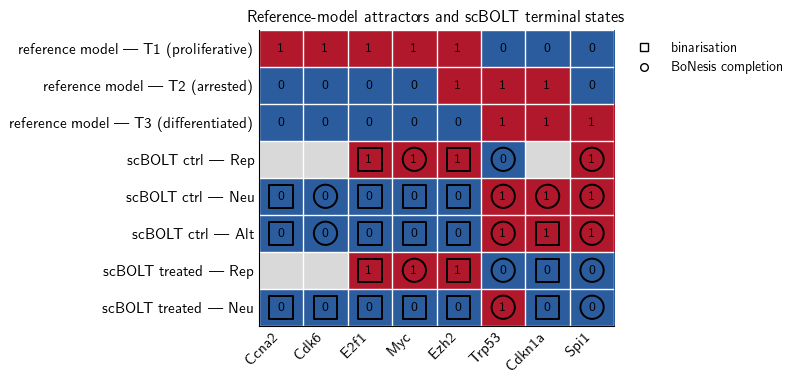

In [16]:
reference_model_file = download_if_missing(
    REFERENCE_MODEL_URL,
    REFERENCE_MODEL_FILE,
)
reference_model = bt.logic.io.read_zginml(reference_model_file)
reference_bn, reference_ig = translate_reference_model(reference_model)
reference_mpbn = mpbn.MPBooleanNetwork(reference_bn.to_bnet())

reference_initial_states = {
    label: as_mpbn_state(
        reference_model.initial_states[f"PLZF_RARA_{suffix}"]
    )
    for suffix, label in REFERENCE_MODEL_ATRA_LABELS.items()
}

reference_attractors = {
    name: list(reference_mpbn.attractors(reachable_from=input_state))
    for name, input_state in reference_initial_states.items()
}

reference_component_names = {
    attributes["reference_component"]: component
    for component, attributes in reference_ig.nodes(data=True)
}
reference_phenotypes = {
    phenotype: [
        reference_component_names[component]
        for component in reference_components
    ]
    for phenotype, reference_components in REFERENCE_MODEL_PHENOTYPES.items()
}

display(
    pd.DataFrame(
        [
            {"phenotype": phenotype, "components": ", ".join(components)}
            for phenotype, components in reference_phenotypes.items()
        ]
    ).style.hide(axis="index")
)

reference_input_components = {
    component
    for component, attributes in reference_ig.nodes(data=True)
    if attributes.get("input", False)
}
unique_reference_attractor_states = []
reference_attractor_accessibility = defaultdict(list)

for initial_state, attractors in reference_attractors.items():
    for attractor in attractors:
        internal_state = {
            component: value
            for component, value in attractor.items()
            if component not in reference_input_components
        }
        if internal_state not in unique_reference_attractor_states:
            unique_reference_attractor_states.append(internal_state)

        attractor_label = (
            f"T{unique_reference_attractor_states.index(internal_state) + 1}"
        )
        reference_attractor_accessibility[attractor_label].append(initial_state)

reference_unique_attractors = {
    f"T{index}": attractor
    for index, attractor in enumerate(unique_reference_attractor_states, start=1)
}
reference_attractor_phenotypes = {
    attractor_label: next(
        (
            phenotype
            for phenotype in REFERENCE_MODEL_PHENOTYPE_PRIORITY
            if all(
                attractor.get(component) == 1
                for component in reference_phenotypes[phenotype]
            )
        ),
        "unclassified",
    )
    for attractor_label, attractor in reference_unique_attractors.items()
}

reference_attractor_summary = pd.DataFrame(
    [
        {
            "attractor": attractor_label,
            "phenotype": reference_attractor_phenotypes[attractor_label],
            "accessible from": ", ".join(
                reference_attractor_accessibility[attractor_label]
            ),
        }
        for attractor_label in reference_unique_attractors
    ]
)
display(reference_attractor_summary.style.hide(axis="index"))

display_counts(
    {
        "reference-model components": len(reference_bn),
        "unique internal MP attractors": len(unique_reference_attractor_states),
        **{
            f"MP attractors from {name}": len(attractors)
            for name, attractors in reference_attractors.items()
        },
    },
    index_name="item",
    count_name="n",
)

(
    reference_panel_columns,
    mapped_panel_components,
    excluded_panel_components,
) = build_reference_panel_columns(reference_bn, components)

if mapped_panel_components:
    display(
        pd.DataFrame(
            mapped_panel_components,
            columns=["reference component", "scBOLT component"],
        ).style.hide(axis="index")
    )

if excluded_panel_components:
    display(
        pd.DataFrame(
            excluded_panel_components,
            columns=["component", "reason"],
        ).style.hide(axis="index")
    )

reference_comparison_states = {
    f"{attractor_label} ({reference_attractor_phenotypes[attractor_label]})": attractor
    for attractor_label, attractor in reference_unique_attractors.items()
}
reference_state_table, reference_state_origin = reference_state_comparison_table(
    reference_comparison_states,
    configs,
    mstate_hypercubes,
    reference_panel_columns,
)

display(
    reference_state_table.style
    .set_caption("Reference-model attractors and scBOLT terminal-state consensus")
    .format("{:.0f}", na_rep="")
)

fig, ax = plot_binary_state_table(reference_state_table, reference_state_origin)
ax.set_title(
    "Reference-model attractors and scBOLT terminal states",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "reference_model_state_comparison.pdf", bbox_inches="tight")
plt.show()
plt.close()


In [17]:
# REFERENCE_MODEL_INPUTS

# reference_model = bt.logic.io.read_zginml(reference_model_file)

# reference_model.initial_states
#reference_model.perturbations

#bn = reference_model.boolean_network.copy()
#
#for source, target in REFERENCE_MODEL_ALIASES.items():
#    if source in bn:
#        bn.rename(source, target)
#
#protected = sorted(REFERENCE_MODEL_PROTECTED_COMPONENTS & set(bn.keys()))
#locks = {component: f"MODELLOCK{i}X" for i, component in enumerate(protected)}
#for component, lock in locks.items():
#    bn.rename(component, lock)
#
#bn = human_genesyn.standardize_bn(bn, copy=True)
#bn = hcop_orthologs.translate_bn(bn, keep_if_missing=True, copy=True)
#bn = genesyn.standardize_bn(bn, copy=True)
#
#for component, lock in locks.items():
#    bn.rename(lock, component)




## Reachable attractors <a class="anchor" id="attractors"></a>

In [18]:
# help(bt.logic.io.read_hypercubes)

# mpbns = bns.convert("mpbn")
# 
# init = ["ctrl_Prom1", "treated_Prom1"]
# 
# configs[0]
# bns[0]
# 
# for name in ["ctrl_Prom1"]:
#     attractor_number = pd.Series([len(list(bn.attractors(reachable_from=config[name]))) for bn, config in zip(mpbns, mpbn_configs)]).value_counts().to_dict()


In [19]:
#n_trapspaces = pd.Series(
#    [len(list(mpbn.minimal_trapspaces())) for mpbn in mpbns]
#).value_counts().to_dict()
#
#plot_counts(
#    n_trapspaces,
#    title="minimal trap spaces"
#)
#
#plt.show()
#plt.close()

#k, v = [], []
#for n in sorted(attractor_number.keys()):
#    k.append(n)
#    v.append(attractor_number[n])
#fig, ax = plt.subplots(nrows=1, ncols=1)
#plt.bar(k, v, width=1, facecolor=bt.omics.pl.get_color("pink"), edgecolor=bt.omics.pl.get_color("red"), linewidth=1.5)
#plt.xlim([k[0]-0.6, k[-1]+0.6])
#plt.ylim(0, max(v)+1)
#plt.title("minimal trap spaces")
#plt.show()
#plt.close()

## Subset-minimal Boolean networks <a class="anchor" id="minimal"></a>

In [20]:
import math

import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 60

bns = []
cfgs = []

macrostates = pd.read_csv("data/interest/bin/bin_macrostates.csv", index_col=0).transpose()
for c in set(components) - set(macrostates.index):
    macrostates.loc[c] = pd.Series()
macrostates = macrostates.loc[components,:].replace(math.nan, "*").to_dict()
for k, v in macrostates.items():
    macrostates[k] = bt.logic.Hypercube(v)

configuration_space = dict()
for condition, macrostate in macrostates.items():
    to_remove = []
    for k, v in macrostate.items():
        if isinstance(v, str):
            to_remove.append(k)

    configuration_space[condition] = {
        "n_free_components": len(to_remove),
        "n_configurations": 2 ** len(to_remove),
    }
    for k in to_remove:
        del macrostate[k]

configuration_space = pd.DataFrame.from_dict(configuration_space, orient="index")
configuration_space.index.name = "macrostate"
display(configuration_space)

for i in range(100):
    bns.append(mpbn.MPBooleanNetwork.load(f"data/interest/bn/sub/{i}/sub.bnet"))
    cfg = pd.read_csv(f"data/interest/bn/sub/{i}/metastates.csv", index_col=0).to_dict()
    for k, v in cfg.items():
        cfg[k] = bt.logic.Hypercube(v)
    cfgs.append(cfg)
    del cfg

bns = bt.logic.BooleanNetworkEnsemble(bns=bns)
components = list(bns.get_components())

attractor_number = pd.Series([len(list(bn.attractors())) for bn in bns]).value_counts().to_dict()
k, v = [], []
for n in sorted(attractor_number.keys()):
    k.append(n)
    v.append(attractor_number[n])
fig, ax = plt.subplots(nrows=1, ncols=1)
plt.bar(k, v, width=1, facecolor=bt.omics.pl.get_color("pink"), edgecolor=bt.omics.pl.get_color("red"), linewidth=1.5)
plt.xlim([k[0]-0.5, k[-1]+0.6])
plt.ylim(0, max(v)+1)
plt.title("From any configurations")
plt.show()
plt.close()

for name in ["ctrl_promyelocytes", "treated_promyelocytes"]:
    attractor_number = pd.Series([len(list(bn.attractors(reachable_from=cfg[name]))) for cfg, bn in zip(cfgs, bns)]).value_counts().to_dict()
    k, v = [], []
    for n in sorted(attractor_number.keys()):
        k.append(n)
        v.append(attractor_number[n])
    fig, ax = plt.subplots(nrows=1, ncols=1)
    plt.bar(k, v, width=1, facecolor=bt.omics.pl.get_color("pink"), edgecolor=bt.omics.pl.get_color("red"), linewidth=1.5)
    plt.xlim([k[0]-0.5, k[-1]+0.6])
    plt.ylim(0, max(v)+1)
    plt.xticks(k)
    plt.title(f"From configuration {name}")
    plt.show()
    plt.close()

for name in ["ctrl_prom1", "treated_prom1"]:
    attractor_number = pd.Series([len(list(bn.attractors(reachable_from=macrostates[name]))) for bn in bns]).value_counts().to_dict()
    k, v = [], []
    for n in sorted(attractor_number.keys()):
        k.append(n)
        v.append(attractor_number[n])
    fig, ax = plt.subplots(nrows=1, ncols=1)
    plt.bar(k, v, width=1, facecolor=bt.omics.pl.get_color("pink"), edgecolor=bt.omics.pl.get_color("red"), linewidth=1.5)
    plt.xlim([k[0]-0.5, k[-1]+0.6])
    plt.ylim(0, max(v)+1)
    plt.xticks(k)
    plt.title(f"From macrostate {name}")
    plt.show()
    plt.close()

FileNotFoundError: [Errno 2] No such file or directory: 'data/interest/bin/bin_macrostates.csv'

In [ ]:
macrostate_size_summary = display_counts(
    {name: len(macrostate) for name, macrostate in macrostates.items()},
    index_name="macrostate",
    count_name="n_defined_components",
)
